In [ ]:
# CELL 1 — train RoBERTa and return objects (model, tokenizer, val dataset, history)

import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ---- Config ----
TRAIN_CSV = "data/twitter_training.csv"
VAL_CSV   = "data/twitter_validation.csv"
MODEL_NAME= "roberta-base"
EPOCHS    = 3
BATCH     = 16
LR        = 2e-5
MAX_LEN   = 128

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---- Load CSVs (no header: id, topic, label, text) ----
train_df = pd.read_csv(TRAIN_CSV, header=None, names=["id","topic","label","text"], keep_default_na=False)
val_df   = pd.read_csv(VAL_CSV,   header=None, names=["id","topic","label","text"], keep_default_na=False)

# Data Preparation - Map labels to ints
# Derive the class vocabulary from training data only.
classes = sorted(train_df["label"].astype(str).unique())
label2id = {c:i for i,c in enumerate(classes)}
id2label = {i:c for c,i in label2id.items()}
train_df["y"] = train_df["label"].map(label2id).astype(int)
val_df["y"]   = val_df["label"].map(label2id).astype(int)
num_labels = len(classes)
print("Label mapping:", label2id)

# ---- Dataset ----
class TxtDS(Dataset):
    def __init__(self, texts, labels, tokenizer):
        texts = [str(t) for t in texts.tolist()]
        enc = tokenizer(texts, padding="max_length", truncation=True,
                        max_length=MAX_LEN, return_tensors="pt")
        self.enc = enc
        self.y = torch.tensor(labels.tolist(), dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item["labels"] = self.y[i]
        return item

# ---- Train + Eval (returns model, tokenizer, val-dataset, history, and helpers) ----
def train_and_eval(model_name):
    print(f"\n=== {model_name} ===")
    tok = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    tr_ds = TxtDS(train_df["text"], train_df["y"], tok)
    va_ds = TxtDS(val_df["text"],   val_df["y"],   tok)
    tr_loader = DataLoader(tr_ds, batch_size=BATCH, shuffle=True)
    va_loader = DataLoader(va_ds, batch_size=BATCH)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=num_labels, id2label=id2label, label2id=label2id
    ).to(device)
    optim = torch.optim.AdamW(model.parameters(), lr=LR)

    history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}

    for epoch in range(1, EPOCHS+1):
        print(f"\n--- Epoch {epoch}/{EPOCHS} ---")
        # train
        model.train()
        tot_loss = tot_correct = tot_count = 0
        for batch in tr_loader:
            batch = {k: v.to(device) for k,v in batch.items()}
            optim.zero_grad()
            out = model(**batch)
            loss = out.loss
            loss.backward()
            optim.step()
            preds = out.logits.argmax(dim=-1)
            n = batch["labels"].size(0)
            tot_loss   += loss.item() * n
            tot_correct+= (preds == batch["labels"]).sum().item()
            tot_count  += n
        train_loss = tot_loss / tot_count
        train_acc  = tot_correct / tot_count

        # validate
        model.eval()
        tot_loss = tot_correct = tot_count = 0
        with torch.no_grad():
            for batch in va_loader:
                batch = {k: v.to(device) for k,v in batch.items()}
                out = model(**batch)
                loss = out.loss
                preds = out.logits.argmax(dim=-1)
                n = batch["labels"].size(0)
                tot_loss   += loss.item() * n
                tot_correct+= (preds == batch["labels"]).sum().item()
                tot_count  += n
        val_loss = tot_loss / tot_count
        val_acc  = tot_correct / tot_count

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch}/{EPOCHS} | "
              f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} acc={val_acc:.4f}")

    return history, model, tok, va_ds, id2label, num_labels, BATCH, device

# Run training and keep everything for the next cell
hist_rbt, model_rbt, tok_rbt, va_ds_rbt, id2label_rbt, num_labels_rbt, BATCH_rbt, device_rbt = train_and_eval(MODEL_NAME)


c:\Users\Ali\Documents\COMP 6721 AAI Project\Project\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Label mapping: {'Irrelevant': 0, 'Negative': 1, 'Neutral': 2, 'Positive': 3}

=== roberta-base ===


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Epoch 1/3 ---
Epoch 1/3 | train_loss=0.8299 acc=0.6675 | val_loss=0.4159 acc=0.8570

--- Epoch 2/3 ---
Epoch 2/3 | train_loss=0.4258 acc=0.8415 | val_loss=0.1502 acc=0.9580

--- Epoch 3/3 ---
Epoch 3/3 | train_loss=0.2407 acc=0.9085 | val_loss=0.1060 acc=0.9710


Saved fine-tuned RoBERTa + tokenizer to: roberta_finetuned

=== RoBERTa Validation Metrics ===
Accuracy: 0.971

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.98      0.94      0.96       172
    Negative       0.99      0.97      0.98       266
     Neutral       0.94      0.98      0.96       285
    Positive       0.97      0.97      0.97       277

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000

Confusion Matrix (rows=true, cols=pred):
[[162   1   7   2]
 [  0 259   5   2]
 [  2   0 280   3]
 [  1   1   5 270]]


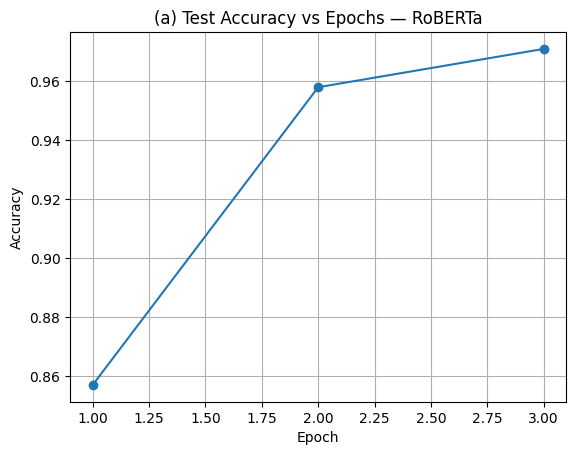

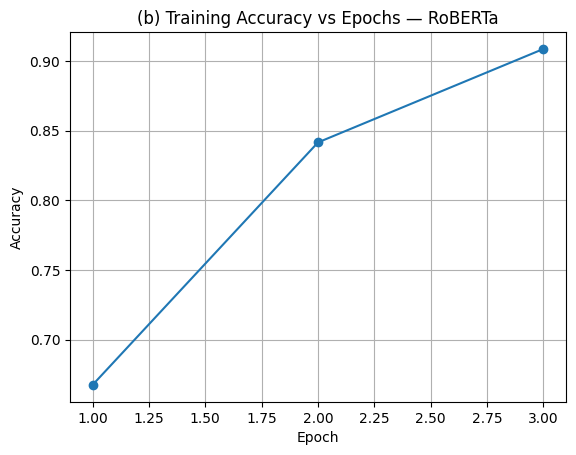

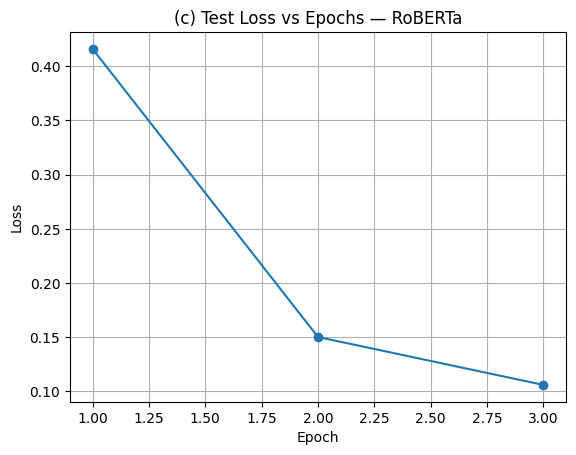

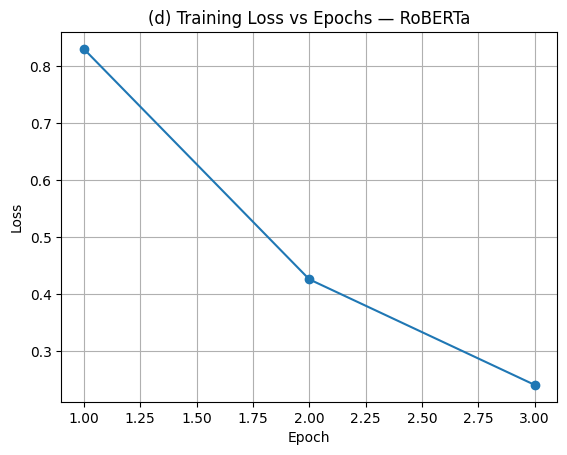

In [2]:
# CELL 2 — save RoBERTa model/tokenizer, compute validation metrics, and plot curves
# pip install scikit-learn matplotlib numpy  (if not already installed)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

SAVE_DIR_RBT = "roberta_finetuned"

# 1) Save fine-tuned model + tokenizer
model_rbt.save_pretrained(SAVE_DIR_RBT)
tok_rbt.save_pretrained(SAVE_DIR_RBT)
print(f"Saved fine-tuned RoBERTa + tokenizer to: {SAVE_DIR_RBT}")

# 2) Validation metrics (confusion matrix, precision/recall/F1)
va_loader_rbt = DataLoader(va_ds_rbt, batch_size=BATCH_rbt, shuffle=False)
model_rbt.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in va_loader_rbt:
        batch = {k: v.to(device_rbt) for k, v in batch.items()}
        logits = model_rbt(**batch).logits
        all_preds.append(logits.argmax(dim=-1).cpu().numpy())
        all_labels.append(batch["labels"].cpu().numpy())
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

print("\n=== RoBERTa Validation Metrics ===")
print("Accuracy:", accuracy_score(all_labels, all_preds))
print("\nClassification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=[id2label_rbt[i] for i in range(num_labels_rbt)],
    zero_division=0
))
print("Confusion Matrix (rows=true, cols=pred):")
print(confusion_matrix(all_labels, all_preds))

# 3) Plots (learning curves from hist_rbt)
epochs = range(1, len(hist_rbt["val_acc"])+1)
plt.figure(); plt.plot(list(epochs), hist_rbt["val_acc"], marker="o"); plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("(a) Validation Accuracy vs Epoch — RoBERTa"); plt.grid(True); plt.show()
plt.figure(); plt.plot(list(epochs), hist_rbt["train_acc"], marker="o"); plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("(b) Training Accuracy vs Epoch — RoBERTa"); plt.grid(True); plt.show()
plt.figure(); plt.plot(list(epochs), hist_rbt["val_loss"], marker="o"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("(c) Validation Loss vs Epoch — RoBERTa"); plt.grid(True); plt.show()
plt.figure(); plt.plot(list(epochs), hist_rbt["train_loss"], marker="o"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("(d) Training Loss vs Epoch — RoBERTa"); plt.grid(True); plt.show()


In [3]:
metrics_df = pd.DataFrame({
    "epoch": range(1, len(hist_rbt["train_loss"]) + 1),
    "train_loss": hist_rbt["train_loss"],
    "train_acc":  hist_rbt["train_acc"],
    "val_loss":   hist_rbt["val_loss"],
    "val_acc":    hist_rbt["val_acc"]
})

METRICS_FILE = "roberta_metrics.csv"
metrics_df.to_csv(METRICS_FILE, index=False)
print(f"Saved metrics to {METRICS_FILE}")
print(metrics_df)

Saved metrics to roberta_metrics.csv
   epoch  train_loss  train_acc  val_loss  val_acc
0      1    0.829854   0.667497  0.415933    0.857
1      2    0.425836   0.841475  0.150170    0.958
2      3    0.240661   0.908532  0.105977    0.971
